# Day 004 · 金融市场基础速览 · 中国版
**Asset Classes 101** · 阶段 P1 · 量化基础

> 量化要能跨市场思考。今天 25 分钟带你过一遍能交易的所有大类资产、各自的特征、流动性、量化适合度。看完你会知道:不是所有资产都适合量化,也不是所有量化都需要去最复杂的市场。中国大陆居民的特殊限制(QDII / 港美券商) 我们也讲清楚。

---

### 关于「中国版」

本 notebook 是为**国内学员**优化的版本:
- 数据源用 **akshare**(国内可访问、零 VPN、免注册),取代了视频里的 yfinance
- 标的尽量保持原意:美股 ETF→A 股 ETF / 国际公司→A 股龙头
- 所讲的**概念和方法 100% 一致**,但**具体数字可能与视频里略有差异**(因为是不同时间窗 / 不同标的)
- 一般情况国内 `pip install akshare` 即可,无需 token / VPN

**课件生成日期:** 2026-05-04  ·  **建议学习时长:** 22 分钟

## 🔧 第一步:环境自检 + 自动安装

**第一次拿到这份 notebook,请先运行下面这一格。** 它会:
1. 检查所有必需的 Python 包(含 `akshare`),缺什么自动 `pip install` 装上
2. 注入中文字体到 matplotlib(让图标不出乱码)
3. 跑完看到 `✓ 环境就绪` 就可以继续


In [1]:
# === 环境自检 + 自动安装(运行此单元格即可)===
import importlib, subprocess, sys, os

REQUIRED = ["akshare", "matplotlib", "numpy", "numpy_financial", "pandas", "scipy", "sklearn", "statsmodels"]
PIP_NAME = {"sklearn":"scikit-learn","cv2":"opencv-python","PIL":"Pillow","bs4":"beautifulsoup4","yaml":"PyYAML"}

missing = []
for mod in REQUIRED:
    try:
        importlib.import_module(mod)
    except ImportError:
        missing.append(PIP_NAME.get(mod, mod))
if missing:
    print(f"⏳ 缺少 {len(missing)} 个包,自动安装:{missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    print("✓ 安装完成")
else:
    print(f"✓ 所有 {len(REQUIRED)} 个必需库已就绪")

# === 中文字体配置 ===
import matplotlib, matplotlib.pyplot as plt, matplotlib.font_manager as fm
CJK = ["/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
       "C:/Windows/Fonts/msyh.ttc","C:/Windows/Fonts/simhei.ttf",
       "/System/Library/Fonts/PingFang.ttc","/System/Library/Fonts/STHeiti Medium.ttc"]
for p in CJK:
    if os.path.exists(p):
        fm.fontManager.addfont(p)
        print(f"✓ 中文字体已加载:{os.path.basename(p)}")
        break
plt.rcParams["font.sans-serif"] = ["Noto Sans CJK JP","Microsoft YaHei","PingFang SC","SimHei","DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
print("✓ 环境就绪")


✓ 所有 8 个必需库已就绪
✓ 中文字体已加载:NotoSansCJK-Regular.ttc
✓ 环境就绪


## 🔌 第二步:加载国内数据助手

下面这一格是**工具函数**(可以折叠,不需要修改)。它把 `yfinance` 风格的 ticker(如 `600519.SS`)自动路由到对应的 akshare 接口,提供 `get_close(ticker)` 和 `get_close_multi(tickers_dict)` 两个函数。

In [2]:
# === 国内数据源助手(akshare 后端,不需要 VPN)===
# 这一格是工具函数,可以折叠,不需要修改。
# 它把 yfinance 风格的 ticker(如 "600519.SS" / "0700.HK" / "AAPL" / "BTC-USD")
# 自动路由到对应的 akshare 接口,统一返回 yfinance 风格的 Close DataFrame。

import re
from datetime import datetime, timedelta
import pandas as pd
import akshare as ak

_TICKER_MAP = {
    "^GSPC": ("us_index_sina", ".INX"),
    "^DJI":  ("us_index_sina", ".DJI"),
    "^IXIC": ("us_index_sina", ".IXIC"),
    "GC=F":  ("foreign_futures", "GC"),
    "SI=F":  ("foreign_futures", "SI"),
    "CL=F":  ("foreign_futures", "CL"),
    "BTC-USD": ("crypto", "BTC"),
    "ETH-USD": ("crypto", "ETH"),
}

def _parse_period(period):
    end = datetime.today()
    m = re.match(r"^(\d+)\s*(y|mo|d|w)$", period.lower().strip())
    days = 365 * 3 if not m else int(m.group(1)) * {"y":365,"mo":30,"w":7,"d":1}[m.group(2)]
    return (end - timedelta(days=days+30)).strftime("%Y%m%d"), end.strftime("%Y%m%d")

def _classify(ticker):
    t = ticker.strip()
    if t in _TICKER_MAP: return _TICKER_MAP[t]
    if t.endswith((".SS",".SH",".SZ")):
        code = t.split(".")[0]
        if code.startswith(("51","159","58")) or code in ("510300","510500","510050","511010","513100"):
            return ("a_etf", code)
        if code in ("000300","000016","000905","000852","000001"):
            return ("a_index", code)
        return ("a_stock", code)
    if t.endswith(".HK"):
        return ("hk", t.split(".")[0].zfill(5))
    return ("us", t)

def _norm(df, dc, cc):
    out = df[[dc, cc]].copy()
    out[dc] = pd.to_datetime(out[dc])
    return out.set_index(dc).sort_index()[cc].astype(float).rename("Close")

def get_close(ticker, period="3y"):
    """返回某标的 Close 价格 series。后端 akshare,中国可访问。"""
    start, end = _parse_period(period)
    kind, sym = _classify(ticker)
    if kind == "a_stock":
        return _norm(ak.stock_zh_a_hist(symbol=sym, period="daily", start_date=start, end_date=end, adjust="qfq"), "日期", "收盘")
    if kind == "a_etf":
        return _norm(ak.fund_etf_hist_em(symbol=sym, period="daily", start_date=start, end_date=end, adjust="qfq"), "日期", "收盘")
    if kind == "a_index":
        idx_map = {"000300":"sh000300","000016":"sh000016","000905":"sh000905","000852":"sh000852","000001":"sh000001"}
        s = _norm(ak.stock_zh_index_daily_em(symbol=idx_map.get(sym, f"sh{sym}")), "date", "close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    if kind == "hk":
        return _norm(ak.stock_hk_hist(symbol=sym, period="daily", start_date=start, end_date=end, adjust="qfq"), "日期", "收盘")
    if kind == "us":
        # 美股走新浪源(stock_us_daily 直接吃 NVDA / AAPL 裸 symbol;stock_us_hist 要带前缀)
        s = _norm(ak.stock_us_daily(symbol=sym, adjust="qfq"), "date", "close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    if kind == "us_index_sina":
        s = _norm(ak.index_us_stock_sina(symbol=sym), "date", "close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    if kind == "foreign_futures":
        s = _norm(ak.futures_foreign_hist(symbol=sym), "date", "close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    if kind == "crypto":
        # akshare 没稳定的 crypto_hist(2026-05 已移除/改名)。
        # 直接调 Binance 公共 API,国内可访问、无需 SDK。
        import requests as _rq
        r = _rq.get("https://api.binance.com/api/v3/klines",
                    params={"symbol": f"{sym}USDT", "interval": "1d", "limit": 1000}, timeout=15)
        r.raise_for_status()
        df = pd.DataFrame(r.json(), columns=["open_time","open","high","low","close","volume",
                                              "close_time","qav","trades","tbb","tbq","ignore"])
        df["date"] = pd.to_datetime(df["open_time"], unit="ms")
        df["close"] = df["close"].astype(float)
        s = df.set_index("date").sort_index()["close"].rename("Close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    raise ValueError(f"unsupported ticker: {ticker}")

def get_close_multi(tickers, period="3y"):
    """批量取 Close,返回 DataFrame,列名是 tickers dict 的 key(中文名),按交集日期对齐。"""
    series = {name: get_close(t, period=period) for name, t in tickers.items()}
    return pd.concat(series, axis=1).sort_index()

print("✓ cn_data 助手已加载 — 用 get_close(ticker) / get_close_multi(tickers_dict) 拉数据")


✓ cn_data 助手已加载 — 用 get_close(ticker) / get_close_multi(tickers_dict) 拉数据


## 学习目标

- 区分主要资产类:股票/债券/期货/期权/外汇/加密 各自的本质
- 知道每类资产的交易时间、结算规则、量化适合度
- 看懂跨市场套利的逻辑(AH 折溢价、ETF 折价、跨期 / 期现)
- 评估自己的资金能进哪些市场、不能进哪些市场
- 选定 1-2 个主战场重点投入,而不是什么都做一遍

## 历史背景:全球资产五大板块和散户的真实通道

全球可交易资产可以粗分为五大板块:美/欧/中(含港)/亚(日韩印)/加密。其中只有'美 + 中港 + 加密'对中国大陆散户实操友好,欧洲和日本市场基本看不动也没顺手通道。

中国大陆居民的特殊限制:
- A 股:门槛最低,Tushare/akshare 免费数据,但 T+1 + 个股做空困难
- 港股:港美券商(富途/老虎/盈透)开户即可,T+0 + 双向做空,信息环境介于 A 美之间
- 美股:同上,但要面对外汇额度(每年 5 万美元)和深夜交易时间
- 期货:商品 + 股指期货国内开户即可(50 万验资门槛),CFTC 美国期货需要美国账户
- 期权:50ETF / 300ETF / 个股期权(高门槛)国内可做,美股期权需要美国账户
- 加密:监管不允许大陆开户,海外渠道存在合规和资金安全风险

所以散户的实际可做集合是:A 股 + 港股 + 美股 + 国内期货期权 + 加密(高合规风险)。其余资产先看不做。

**关键人物:**
- Tushare 免费 A 股数据
- 港美券商(富途/老虎/盈透)
- 中金所国内期货
- OKX/Binance 加密(合规风险)

## 核心概念

下面每一节是听完视频后回头细读的内容。

### 1. 股票市场:A 股 / 港股 / 美股的本质差异

A 股(沪深北):约 5300 只股票,T+1 交易,涨跌停 ±10%(创业板/科创板 ±20%),个股做空高门槛(融券)。优点:数据免费、流动性整体好。缺点:做空难、政策影响大。量化主战场。

港股:约 2500 只股票,T+0,无涨跌停(部分有触发熔断),双向做空便利。优点:与 A 股 AH 折溢价套利、做空友好。缺点:小盘流动性差、信息环境复杂。

美股(NYSE / NASDAQ):约 8000+ 股票 + 3000+ ETF,T+0,无涨跌停,做空通用。优点:数据丰富、工具成熟、全球最深市场。缺点:中国大陆资金通道(年度 5 万美元额度)+ 时差(中国晚上交易)。

散户优先级:起步 A 股 → 加港股做空验证 → 美股做大策略池。

> **举例:** 贵州茅台同时在 A 股(600519)和...其实 A 股茅台没有 H 股。但工商银行 A(601398)和港股工行(1398)同时存在,AH 价差时常 10-20%,是经典套利对子。


### 2. 债券市场:利率 / 信用 / 可转债

国内债券分三块:
- 国债 / 地方债 / 政策金融债:利率债,与利率走势挂钩,流动性好,机构主导
- 信用债(企业债 / 公司债 / 短融):信用风险溢价,违约会跌穿,中等流动性
- 可转债:债 + 股票期权,国内可转债市场是散户量化的'微型乐园',2017-2024 年化 15-20% 不难

散户量化债券的最现实选项:可转债打新 + 双低策略。利率债和信用债基本被机构垄断,信息和资金成本散户没优势。

> **举例:** 可转债打新中签率约 0.001%,但每签上市首日平均涨 20-40%。无脑申购 + 上市当天卖出,中等运气一年 1-2 万元额外收益,纯粹的捡钱。


### 3. 期货 + 期权:杠杆与保证金

国内期货:
- 商品期货:农产品(豆/玉米/棉/糖)、黑色(螺纹/铁矿/焦煤)、化工(PTA/甲醇/PVC)、有色(铜/铝/锌/镍)、贵金属(金/银)。门槛低,基本无验资。
- 金融期货:股指期货(IF/IH/IC/IM)、国债期货(TF/T/TS),需要 50 万验资 + 适当性测试

国内期权:50ETF / 300ETF / 部分商品期权 / 个股期权(50 万验资门槛)。期权波动率交易、备兑开仓是散户友好策略。

关键点:保证金 = 杠杆。期货 5-15% 保证金 = 6-20 倍杠杆。新手永远先小仓位试水,爆仓教训只需要一次。

> **举例:** 国内做螺纹钢期货:1 手 = 10 吨,价格 4000 元/吨,合约价值 4 万元,保证金 10% = 4000 元。1 手就能对应 4 万的螺纹钢,杠杆 10 倍。


### 4. 加密 + 外汇:24×7 与监管

加密市场:7×24 不停盘,无涨跌停,杠杆从 1x 到 100x 都有。BTC/ETH 流动性最好,小币种'土狗'风险极高。Binance/OKX/Bybit 是头部交易所。中国大陆居民开户处于灰色地带,监管和资金通道都有合规问题。

外汇:全球最大市场(日均 7.5 万亿美元),但中国大陆个人参与基本不可行(国内禁、海外不靠谱)。理论上散户可做但实操不推荐,把精力放在股+期货+期权上。

散户量化加密的可行项目:funding rate 套利(8% 左右年化 + 低风险)、跨所价差(机会变少)、网格交易(震荡市)。

> **举例:** BTC 永续合约 funding rate 长期均值 +0.01%/8h,做空永续 + 现货对冲,年化净 ~10-15%,风险极低。是散户量化最容易上手的真实 alpha,但合规要自己评估。


### 5. 跨市场对比表 + 量化适合度

横向对比 7 类市场的结算速度、做空难度、量化适合度、散户可达性,以及典型量化策略。

**散户优先级**:A 股 + 港股 + 美股(主)+ 国内期货期权 + 加密 funding(可选)。

| 市场 | 结算 | 做空 | 量化适合度 | 散户可达 | 典型策略 |
| --- | --- | --- | --- | --- | --- |
| A 股 | T+1 | 难 | ★★★★ | ★★★★★ | 因子选股 / 可转债 / ETF 套利 |
| A 股期货 | T+0 | 易 | ★★★★ | ★★★ | CTA / 跨期套利 |
| 港股 | T+0 | 易 | ★★★★ | ★★★★ | AH 套利 / 配对 / 因子 |
| 美股 | T+0 | 易 | ★★★★★ | ★★★ | 因子 / 期权 / 算法交易 |
| 美期权 | T+0 | 易 | ★★★★★ | ★★ | 波动率 / 价差 |
| 加密 | 24/7 | 易 | ★★★★ | ★★ (合规) | funding 套利 / 网格 |
| 外汇 | 24/5 | 易 | ★★★ | ★ | 不推荐 |

> **举例:** 建议起步组合:60% A 股因子选股 + 20% 可转债打新 + 20% 美股 ETF 长期持有。三个市场都覆盖,但每个都不深,先建立全局认知。


## 实操:用 Python 同时拉 5 类资产对比

下面这段代码用 akshare 抓数据,国内零 VPN 跑通。**直接 Run All** 看结果。

**依赖:** `pip install pandas numpy matplotlib akshare statsmodels scipy`

/tmp/ipykernel_349510/2213036073.py:89: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  return pd.concat(series, axis=1).sort_index()


              5 年累计收益(%)  年化波动率(%)  Sharpe(粗估)
A 股(沪深300)          21.2      17.9        0.24
港股(恒生科技 ETF)        51.5      32.6        0.32
美股(SP500)           61.4      15.7        0.78
黄金 ETF             119.4      21.1        1.13
比特币                158.1      50.9        0.62


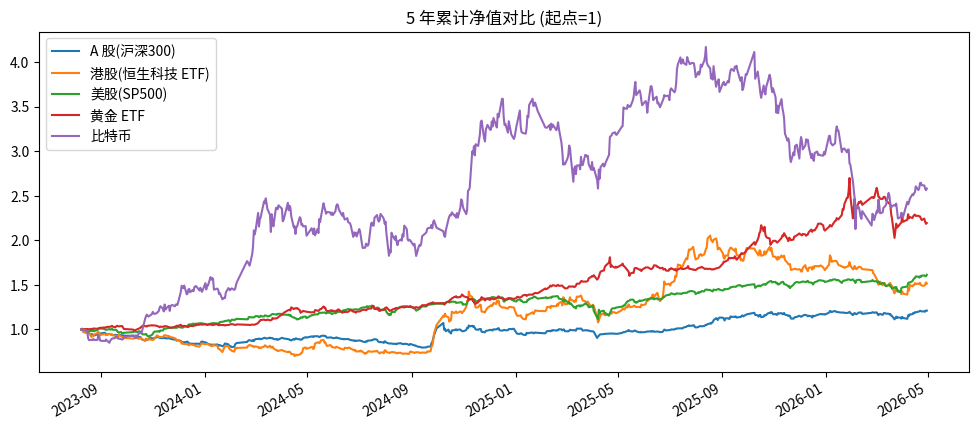

In [3]:
# day_004_asset_classes.py — 一段代码看 5 类资产 5 年走势(中国版)
import pandas as pd
import matplotlib.pyplot as plt

# 5 类资产代表:A 股 / 港股 / 美股 / 黄金 / 加密
# (国内版港股用 513090 恒生科技 ETF;黄金用 518880 黄金 ETF — 国内可申购)
tickers = {
    'A 股(沪深300)': '000300.SS',
    '港股(恒生科技 ETF)': '513090.SS',
    '美股(SP500)':   '^GSPC',
    '黄金 ETF':       '518880.SS',
    '比特币':         'BTC-USD',
}
df = get_close_multi(tickers, period='5y').dropna()
norm = df / df.iloc[0]  # 标准化到 1

# 计算 5 年累计收益和年化波动率
ret_5y = (norm.iloc[-1] - 1) * 100
vol_ann = df.pct_change().std() * (252**0.5) * 100

result = pd.DataFrame({
    '5 年累计收益(%)': ret_5y.round(1),
    '年化波动率(%)':   vol_ann.round(1),
    'Sharpe(粗估)':    (ret_5y / 5 / vol_ann).round(2),
})
print(result.to_string())

norm.plot(figsize=(12, 5), title='5 年累计净值对比 (起点=1)')
plt.savefig('day004_assets.png', dpi=120, bbox_inches='tight')

## 真实市场案例

| 市场 | 标的 | 实战观察 |
| --- | --- | --- |
| A 股 | 600519 茅台 / 000300 沪深300 / 510300 ETF | 茅台 5 年累计 ~150%(波动 50%),沪深300 ~10%(波动 22%),沪深300 ETF 是最容易的 A 股 beta 工具,1 元起买。 |
| 港股 | 0700 腾讯 / 2800 盈富基金 | 腾讯 5 年最大回撤 -70%,2024 反弹 +60%。盈富(2800)跟踪恒指,T+0 + 做空便利,适合做对冲。 |
| 美股 | QQQ / SPY / TLT | QQQ 纳斯达克 100,10 年年化 ~16%。SPY SP500,10 年年化 ~12%。TLT 长期国债,与股票低相关,经典分散组合。 |
| 期货 | 螺纹钢 RB / 沪深300 IF / 焦煤 JM | RB 是国内商品期货流动性王者,适合 CTA 起步。IF 用于股票对冲。JM 季节性强,适合周期策略。 |
| 加密 | BTC / BTC perp / USDT | BTC 现货 + 做空永续合约 = 中性套利,赚 funding rate。Binance 和 OKX 都支持,简单的散户量化入门。 |


## 常见坑

### ⚠ 01. A 股 T+1 + 个股做空难

A 股个股 T+1(今天买明天才能卖)+ 融券池小、利率高(8-12%),纯量化做空个股几乎不可行。变通方案:用股指期货 / ETF 做空整体头寸,个股只做多。

### ⚠ 02. 港股流动性两极分化

港股头部 50 只(腾讯/汇丰/美团等)流动性极好,但 1000 名以后的小盘股可能整天 0 成交。量化必须严格筛流动性,不要看到便宜就买。

### ⚠ 03. 美股交易时间差

美股开盘对应北京时间 21:30(夏)/22:30(冬)。中国交易者主战场是开盘后 2 小时,熬夜或睡觉错过机会。建议用算法单 + 限价单 + 自动化。

### ⚠ 04. 加密合规风险

中国大陆禁止加密交易,境外开户存在多重风险:平台跑路、银行卡冻结、汇兑限制、法律责任。即使做也要小金额、用合规渠道(可能涉及香港/新加坡身份)、自己评估风险。

### ⚠ 05. 期货保证金爆仓

保证金交易 = 杠杆 = 双倍风险。新手在期货市场最常见的死法是仓位过重 + 隔夜跳空。规则:单笔风险 ≤ 1% 总资金、永远不在收盘前 30 分钟加仓。

## 实战 SOP · 散户的市场选择 SOP

1. 起步 0-3 个月:只在 A 股做。免费数据 + 量化主战场 + 不熬夜
2. 3-6 个月:加港股 ETF(2800/2828)做对冲和验证多空策略
3. 6-12 个月:开美股账户跑因子,QQQ/SPY/IWM 做 ETF 因子组合
4. 12+ 个月:可加国内期货期权(50ETF 期权门槛低,商品期货门槛低)
5. 关于加密:合规清楚 + 资金限额 + 用 Binance/OKX 主流所 + 不超过 5% 总资金
6. 永远不做的:外汇杠杆(国内非法 + 海外不靠谱)、欧洲股(信息环境差)
7. 至少 3 个市场的认知,1-2 个的实操深度。深度比广度重要。

> 把这段打印贴在你电脑边。

## 总结 · 你应该带走的

2. 全球资产分五大板块,散户实际可做的是:A 股 + 港股 + 美股 + 国内期货期权 + 加密。
3. A 股 T+1 + 个股做空难,但量化主战场;港股 T+0 适合做对冲和 AH 套利;美股最深但有时差。
4. 可转债打新 + 50ETF 期权是散户最容易上手的'非纯股票'量化机会。
5. 加密对散户最友好的是 funding rate 套利,年化 8-15% 风险较低,但合规自己评估。
6. 期货是杠杆游戏,新手必须先小仓位 + 严格止损,爆仓教训只需要一次。
7. 起步路径:0-3 月 A 股 → 3-6 月加港股 → 6-12 月加美股 → 12+ 月可加期货期权。
8. 外汇散户基本不可做,欧洲日本市场信息环境差,不是不能做是性价比低。
9. 深度 > 广度:1-2 个市场的真功夫,胜过 5 个市场的浅尝辄止。

## 自测题

**Q1.** 你目前手上有 10 万元,从今天起最合理的市场分配方案是什么?

**Q2.** 你想做配对交易,A 股、港股、美股各自的优劣是什么?(提示:做空难易/数据/容量)

**Q3.** 如果只能选 2 个市场作为未来 1 年的主战场,你会选哪 2 个?为什么?

把答案写下来,3 天后再回看。

## 下一节预告

**Day 005 · 收益率的几种算法** (Returns Math)

Day 5:收益率的几种算法 — 看似简单实则关键。如果连'算收益率'都不准,你后面的 Sharpe / 年化 / Calmar 都是错的。今天揭穿一个所有人都犯的小错。

## 推荐阅读

- 《漫步华尔街》Burton Malkiel — 全球资产类入门读物
- Tushare Pro 文档 tushare.pro/document/2 — A 股最详尽的免费数据接口
- yfinance GitHub README — 美股 + 部分港股最便利的免费数据源
- 中金所官网 cffex.com.cn — 国内股指/国债期货合约规格
- 中国证券业协会《投资者适当性管理办法》— 期货/期权门槛规则原文